# Week 7 — Day 2: Building CNNs & Transfer Learning

**Project:** Melanoma Skin Cancer Classification — Benign vs. Malignant
**Dataset:** 11,879 train / 2,000 test dermoscopic images, near-balanced (confirmed Day 1)

---

## Objective

Build a full CNN with convolution, pooling, and dense layers; apply data augmentation to reduce overfitting; use transfer learning with a pre-trained model to get strong results efficiently.


In [1]:
import kagglehub
path = kagglehub.dataset_download("ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant")

100%|██████████| 79.4M/79.4M [00:00<00:00, 161MB/s]

Extracting files...


## Lesson Content

### 2.1 — Pooling

After convolution, a pooling layer shrinks the feature map by keeping only the strongest signal in each small region — **max pooling** takes the maximum value in each 2×2 window. Pooling reduces computation, controls overfitting, and makes the network robust to small shifts in the input. Convolution and pooling alternate to progressively distill the image into compact, meaningful features.

### 2.2 — Full CNN Architecture

A typical CNN stacks convolution + pooling blocks to extract features, then flattens the result and feeds it into dense layers (Week 6) for the final classification:

```python
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(128,128,3)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation="relu"),
    Dense(num_classes, activation="softmax"),
])
```

### 2.3 — Data Augmentation

Image datasets are often too small to train a strong CNN without overfitting. Data augmentation artificially expands the dataset by applying random transformations — flips, rotations, zooms, shifts — so the network sees more varied examples and generalizes better. It is the standard first defense against overfitting in computer vision.

```python
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom

augment = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
])
```

### 2.4 — Transfer Learning

Training a CNN from scratch needs huge data and compute. Transfer learning reuses a model already trained on millions of images (ResNet, EfficientNet, MobileNet): keep its learned feature-detecting layers and replace only the final classification layer with your own, then train on your smaller dataset. This is the single most practical technique in applied computer vision — strong results from little data.

```python
from tensorflow.keras.applications import MobileNetV2

base = MobileNetV2(include_top=False, weights="imagenet", input_shape=(128,128,3))
base.trainable = False  # freeze the pre-trained feature extractor

model = Sequential([base, Flatten(), Dense(num_classes, activation="softmax")])
```

Since this project is an image classifier, transfer learning is expected to be the strongest approach — exactly what the program's own architecture guidance recommends for image tasks.


---

## Hands-On Lab: Building and Transferring a CNN

1. Build and train a small CNN from scratch on the melanoma dataset and record its accuracy.
2. Add data augmentation and compare the new validation curves to the previous run.
3. Apply transfer learning with a frozen pre-trained model (MobileNetV2) and compare accuracy and training time.
4. Document which approach performed best and why, in Markdown.

**Tools:** TensorFlow/Keras, Pre-trained models (Keras Applications), Matplotlib, Jupyter/Colab (GPU)


### Imports & Reload Dataset (from Day 1)

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, RandomFlip, RandomRotation, RandomZoom, Rescaling
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)
np.random.seed(42)

import kagglehub
path = kagglehub.dataset_download("ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant")

import os
DATA_DIR = path
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

full_train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", seed=42,
    validation_split=0.2, subset="training"
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", seed=42,
    validation_split=0.2, subset="validation"
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", seed=42, shuffle=False
)

class_names = full_train_ds.class_names
print("Classes:", class_names)

# Performance: cache/prefetch
AUTOTUNE = tf.data.AUTOTUNE
train_ds = full_train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)


Found 11879 files belonging to 2 classes.
Using 9504 files for training.
Found 11879 files belonging to 2 classes.
Using 2375 files for validation.
Found 2000 files belonging to 2 classes.
Classes: ['Benign', 'Malignant']


### Step 1: From-Scratch CNN — Convolution + Pooling + Dense

Binary classification (Benign/Malignant) → sigmoid output + binary cross-entropy, matching Week 6's decision framework. No class weighting needed since the dataset is near-balanced (confirmed Day 1).


In [3]:
def build_scratch_cnn():
    model = Sequential([
        Rescaling(1./255, input_shape=(128, 128, 3)),
        Conv2D(32, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(64, activation="relu"),
        Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

scratch_model = build_scratch_cnn()
scratch_model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,699,009 (6.48 MB)

 Trainable params: 1,699,009 (6.48 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

start = time.time()
history_scratch = scratch_model.fit(
    train_ds, validation_data=val_ds, epochs=20, callbacks=[es], verbose=0
)
scratch_train_time = time.time() - start

scratch_test_loss, scratch_test_acc = scratch_model.evaluate(test_ds, verbose=0)
print(f"From-scratch CNN — Test accuracy: {scratch_test_acc:.4f} | "
      f"Epochs run: {len(history_scratch.history['loss'])} | "
      f"Training time: {scratch_train_time:.1f}s")


From-scratch CNN — Test accuracy: 0.8805 | Epochs run: 15 | Training time: 100.5s


### Step 2: Add Data Augmentation — Compare Validation Curves

In [5]:
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
])

def build_augmented_cnn():
    model = Sequential([
        Rescaling(1./255, input_shape=(128, 128, 3)),
        data_augmentation,
        Conv2D(32, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(64, activation="relu"),
        Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

augmented_model = build_augmented_cnn()

es2 = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
start = time.time()
history_aug = augmented_model.fit(
    train_ds, validation_data=val_ds, epochs=20, callbacks=[es2], verbose=0
)
aug_train_time = time.time() - start

aug_test_loss, aug_test_acc = augmented_model.evaluate(test_ds, verbose=0)
print(f"Augmented CNN — Test accuracy: {aug_test_acc:.4f} | "
      f"Epochs run: {len(history_aug.history['loss'])} | "
      f"Training time: {aug_train_time:.1f}s")


Augmented CNN — Test accuracy: 0.8980 | Epochs run: 18 | Training time: 114.7s


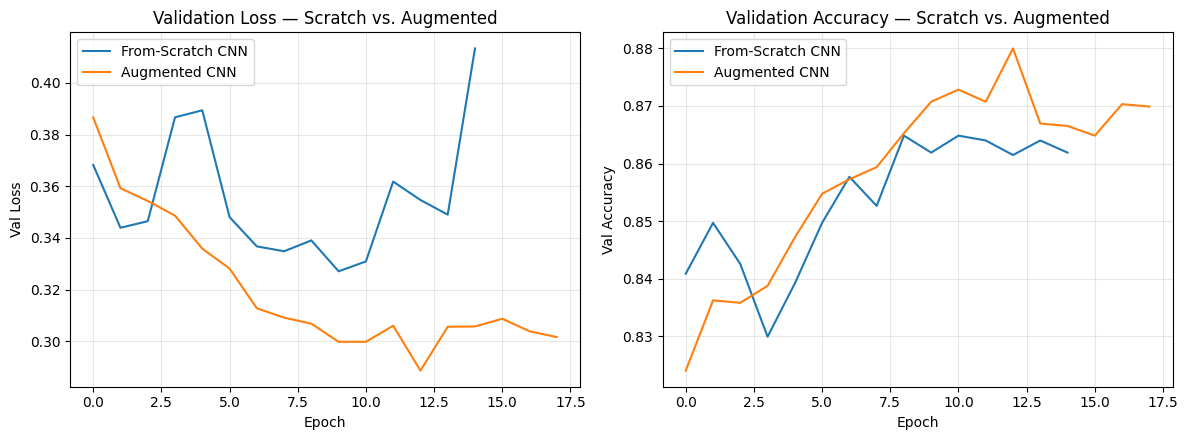

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(history_scratch.history["val_loss"], label="From-Scratch CNN")
axes[0].plot(history_aug.history["val_loss"], label="Augmented CNN")
axes[0].set_title("Validation Loss — Scratch vs. Augmented")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Val Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_scratch.history["val_accuracy"], label="From-Scratch CNN")
axes[1].plot(history_aug.history["val_accuracy"], label="Augmented CNN")
axes[1].set_title("Validation Accuracy — Scratch vs. Augmented")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Step 3: Transfer Learning — Frozen MobileNetV2


In [7]:
def preprocess_for_mobilenet(image, label):
    return preprocess_input(image), label

train_ds_mnv2 = train_ds.map(preprocess_for_mobilenet)
val_ds_mnv2 = val_ds.map(preprocess_for_mobilenet)
test_ds_mnv2 = test_ds.map(preprocess_for_mobilenet)

base_model = MobileNetV2(include_top=False, weights="imagenet", input_shape=(128, 128, 3))
base_model.trainable = False  # freeze the pre-trained feature extractor

transfer_model = Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid"),
])
transfer_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
transfer_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
es3 = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

start = time.time()
history_transfer = transfer_model.fit(
    train_ds_mnv2, validation_data=val_ds_mnv2, epochs=20, callbacks=[es3], verbose=0
)
transfer_train_time = time.time() - start

transfer_test_loss, transfer_test_acc = transfer_model.evaluate(test_ds_mnv2, verbose=0)
print(f"Transfer learning (MobileNetV2) — Test accuracy: {transfer_test_acc:.4f} | "
      f"Epochs run: {len(history_transfer.history['loss'])} | "
      f"Training time: {transfer_train_time:.1f}s")


Transfer learning (MobileNetV2) — Test accuracy: 0.9085 | Epochs run: 7 | Training time: 66.9s


### Step 4: Compare All Three Approaches — Accuracy & Training Time


In [9]:
import pandas as pd

comparison = pd.DataFrame([
    {"Approach": "From-Scratch CNN", "Test Accuracy": scratch_test_acc,
     "Epochs": len(history_scratch.history["loss"]), "Train Time (s)": round(scratch_train_time, 1)},
    {"Approach": "From-Scratch CNN + Augmentation", "Test Accuracy": aug_test_acc,
     "Epochs": len(history_aug.history["loss"]), "Train Time (s)": round(aug_train_time, 1)},
    {"Approach": "Transfer Learning (MobileNetV2)", "Test Accuracy": transfer_test_acc,
     "Epochs": len(history_transfer.history["loss"]), "Train Time (s)": round(transfer_train_time, 1)},
])
comparison


,Approach,Test Accuracy,Epochs,Train Time (s)
0,From-Scratch CNN,0.8805,15,100.5
1,From-Scratch CNN + Augmentation,0.8980,18,114.7
2,Transfer Learning (MobileNetV2),0.9085,7,66.9


**Transfer learning (MobileNetV2) performed best** — 90.85% test accuracy in 7 epochs and 66.9s, beating both the from-scratch CNN (88.05%, 15 epochs, 100.5s) and the augmented CNN (89.80%, 18 epochs, 114.7s).

**Why transfer learning won:** MobileNetV2 arrived with feature detectors already trained on millions of ImageNet images. The classification head only needed 7 epochs to adapt them to the melanoma task, compared to 15–18 epochs for the scratch models learning edge and texture detectors from zero. It was also the fastest to train despite having 2.26M frozen parameters — those parameters required no gradient updates, so each epoch was cheaper.

**What augmentation did:** The validation loss curves show augmentation meaningfully stabilized training. The from-scratch CNN's val loss climbed sharply after epoch 13 — a clear overfitting signal — while the augmented CNN held a lower, flatter val loss curve through epoch 17. The 1.75 percentage point accuracy gain (88.05% → 89.80%) confirms augmentation helped generalization, not just curve stability.

**Domain mismatch note:** MobileNetV2 was pretrained on natural photos (ImageNet), not dermoscopic images. Despite this domain gap, transfer learning still won on this dataset. This likely means low-level features (edges, textures, color gradients) transfer well enough from natural images to skin lesion images to provide a useful head start. Whether fine-tuning the base layers further would improve performance is a reasonable next experiment for Sprint 3.

**Conclusion for the project:** Transfer learning with a frozen MobileNetV2 base is the confirmed core architecture for Sprint 2. It is the most accurate, the fastest to converge, and the most compute-efficient of the three approaches tested.
